# 1 项目介绍
文本分类（Text Classification）是自然语言处理中的一个重要应用技术，根据文档的内容或主题，自动识别文档所属的预先定义的类别标签。在本项目中，我们将借助python和scikit-learn机器学习框架，运用朴素贝叶斯模型来实现针对中文文本的分类任务。

# 2 导入必要的python包
## **naive_bayes**为朴素贝叶斯类库
在scikit-learn中，一共有3个朴素贝叶斯的分类算法类
1) GaussianNB【先验为高斯分布的朴素贝叶斯】，适合样本特征的分布大部分是连续值。
2) MultinomialNB【先验为多项式分布的朴素贝叶斯】，适合样本特征的分布大部分是多元离散值。
3) BernoulliNB【先验为伯努利分布的朴素贝叶斯】，适合样本特征是二元离散值或者很稀疏的多元离散值。

## **TF-IDF特征矩阵**
TF-IDF 特征矩阵是一种用于表示文本数据的数值化方法，广泛应用于信息检索和文本挖掘领域。TF-IDF 是“Term Frequency-Inverse Document Frequency”的缩写，它反映了词语在文档或语料库中的重要性。

### 组成部分

1. **Term Frequency (TF, 词频)**: 表示一个词在文档中出现的频率。通常通过将词在文档中的出现次数除以文档的总词数来计算，这样可以避免因为文档长度不同而带来的偏差。公式如下：  
TF(t)= 词t在文档中出现的次数/文档中的总词数
2. **Inverse Document Frequency (IDF, 逆文档频率)**: 反映了一个词的重要性。常见词（如“是”、“的”等）虽然在很多文档中频繁出现，但对于区分文档作用不大；相反，一些罕见但具有描述性的词更能体现文档的主题。IDF 通过计算所有文档数与包含该词的文档数的比例的对数来衡量这个词的重要性。公式如下：  
IDF(t)=log(包含词t的文档数/总文档数)
3. **TF-IDF**: 结合了 TF 和 IDF 的概念，用来衡量一个词在文档中的重要性。对于某个特定文档中的词 \( t \)，其 TF-IDF 值为：  
TF-IDF(t)=TF(t)×IDF(t)  
这个值越高，意味着这个词越能代表这篇文档的特点，同时在其他文档中不常见。  

### 特征矩阵

  在实际应用中，TF-IDF 被用来构建特征矩阵，其中每一行代表一个文档，每一列代表一个词项（term）。矩阵中的每个元素表示对应词项在对应文档中的 TF-IDF 值。这种表示方法使得文本数据能够被机器学习算法处理，例如分类、聚类等任务。  
  使用 `TfidfVectorizer` 类可以从原始文本数据创建 TF-IDF 特征矩阵。这个过程包括分词、计算词频、计算逆文档频率以及最终生成 TF-IDF 权重。这种方法不仅简化了文本的处理流程，而且有助于提高基于内容的模型性能。

In [1]:
#机器学习模型
from sklearn.naive_bayes import MultinomialNB 
#用于将文本原始数据转化为 TF-IDF 特征矩阵
from sklearn.feature_extraction.text import TfidfVectorizer
#用于划分数据集
from sklearn.model_selection import train_test_split
#用于评估模型性能
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#分词
import jieba
import numpy as np
#用于可视化模型效果
import seaborn as sns
import matplotlib.pyplot as plt

# 3 数据集
THUCNews是根据新浪新闻RSS订阅频道2005~2011年间的历史数据筛选过滤生成，包含74万篇新闻文档（2.19 GB），均为UTF-8纯文本格式。该数据集覆盖了14个不同的主题领域，包括于财经、彩票、房产、股票、家居、教育、科技、社会、时尚、时政、体育、星座、游戏以及娱乐。

在本项目中，我们从THUCNews数据集中挑选了“体育”、“财经”、“房产”、“家居”、“教育”和“科技”这六个领域，每个领域选取了5000篇文章，共计3万篇新闻文档。这些文档被整合进一个TXT文件里，构成了我们项目的基础数据集。

数据集基本格式：每一行为一条新闻，"类别"和"新闻内容"由空格隔开

# 4 训练分类器
## 4.1 数据预处理

In [3]:
#将原始数据集转换成需要的格式
labels=[]
texts=[]
with open(r'filtered_cnews.train.txt','r',encoding='utf-8') as f:
    for line in f:
        # strip()用于移除字符串头尾指定的字符（默认为空格或换行符）；split()中参数1指定分割次数
        parts=line.strip().split('	',1)
        if len(parts)==2:
            labels.append(parts[0])
            texts.append(' '.join(jieba.cut(parts[1])))
#许多机器学习库（包括 scikit-learn）期望输入数据以特定的格式呈现，
#通常这些函数和方法要求输入的数据是 NumPy 数组或类似数组的对象（如 pandas DataFrame）。
#通过将标签列表转换为 NumPy 数组，确保了它们与 scikit-learn 函数兼容。
labels=np.array(labels)
texts=np.array(texts)

#查看数据集
print("类别数：",len(np.unique(labels)))
print("类别：",np.unique(labels))
print("数据量：",len(texts))
print("处理后的新闻文本：",texts[0])

类别数： 6
类别： ['体育' '家居' '房产' '教育' '科技' '财经']
数据量： 30000
处理后的新闻文本： 马晓旭 意外 受伤 让 国奥 警惕   无奈 大雨 格外 青睐 殷家 军 记者 傅亚雨 沈阳 报道   来到 沈阳 ， 国奥队 依然 没有 摆脱 雨水 的 困扰 。 7 月 31 日 下午 6 点 ， 国奥队 的 日常 训练 再度 受到 大雨 的 干扰 ， 无奈 之下 队员 们 只 慢跑 了 25 分钟 就 草草收场 。 31 日 上午 10 点 ， 国奥队 在 奥体中心 外场 训练 的 时候 ， 天 就是 阴沉沉 的 ， 气象预报 显示 当天 下午 沈阳 就 有 大雨 ， 但 幸好 队伍 上午 的 训练 并 没有 受到 任何 干扰 。 下午 6 点 ， 当 球队 抵达 训练场 时 ， 大雨 已经 下 了 几个 小时 ， 而且 丝毫 没有 停下来 的 意思 。 抱 着 试一试 的 态度 ， 球队 开始 了 当天 下午 的 例行 训练 ， 25 分钟 过去 了 ， 天气 没有 任何 转好 的 迹象 ， 为了 保护 球员 们 ， 国奥队 决定 中止 当天 的 训练 ， 全队 立即 返回 酒店 。 在 雨 中 训练 对 足球队 来说 并 不是 什么 稀罕 事 ， 但 在 奥运会 即将 开始 之前 ， 全队 变得 “ 娇贵 ” 了 。 在 沈阳 最后 一周 的 训练 ， 国奥队 首先 要 保证 现有 的 球员 不再 出现意外 的 伤病 情况 以免 影响 正式 比赛 ， 因此 这一 阶段 控制 训练 受伤 、 控制 感冒 等 疾病 的 出现 被 队伍 放在 了 相当 重要 的 位置 。 而 抵达 沈阳 之后 ， 中 后卫 冯萧霆 就 一直 没有 训练 ， 冯萧霆 是 7 月 27 日 在 长春 患上 了 感冒 ， 因此 也 没有 参加 29 日 跟 塞尔维亚 的 热身赛 。 队伍 介绍 说 ， 冯萧霆 并 没有 出现 发烧 症状 ， 但 为了 安全 起 见 ， 这 两天 还是 让 他 静养 休息 ， 等 感冒 彻底 好 了 之后 再 恢复 训练 。 由于 有 了 冯萧霆 这个 例子 ， 因此 国奥队 对雨中 训练 就 显得 特别 谨慎 ， 主要 是 担心 球员 们 受凉 而 引发 感冒 ， 造成 非战斗 减员 。 而 女足 队员 马晓旭 在 热身赛 

## 4.2 数据集划分与特征提取

In [6]:
# 按照8:1:1划分数据集为训练集、验证集和测试集
# 验证集：用来调整超参数（如正则化系数、神经网络中的层数和每层的节点数等），以及选择模型。
#        频繁地在训练集上评估模型可能导致模型过度适应训练数据，而验证集提供了一个独立的数据集来监控模型的泛化能力。
# 测试集：仅用于最终评估模型的性能。因为它从未参与到任何与模型选择或参数调整相关的决策中，从而保证了最终评估结果的有效性和公正性。
X_train, X_temp, y_train, y_temp = train_test_split(texts, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 使用训练集拟合TfidfVectorizer，生成词汇表和TF-IDF权重
# 默认情况下，TfidfVectorizer 使用空格作为分词符。对于中文文本，需先进行分词处理（例如使用 jieba 库）。
# 此处，可以通过stop_words参数，指定词向量空间中的停用词。max_features参数，减少词汇数量，保留出现频率最高的词
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train) #使用的是fit_transform
#基于训练集生成的词汇表，将验证集和测试集文本向量化
X_test=vectorizer.transform(X_test) # 使用的是transform
X_val=vectorizer.transform(X_val)

#查看TF-IDF特征矩阵相关信息
print("词汇表如下：")
print(vectorizer.get_feature_names_out())
print("词汇表中词的数量：")
print(len(vectorizer.get_feature_names_out()))
print("训练数据的向量化表示为：")
# X是一个稀疏矩阵，调用 .toarray() 方法可以将其转换为密集矩阵（普通二维数组）以便查看
print(X_train[:5].toarray())

词汇表如下：
['00' '000' '0000' ... '龟速' '龟钮' '龟鳖']
词汇表中词的数量：
212178
训练数据的向量化表示为：
[[0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.0476265 0.        0.        ... 0.        0.        0.       ]]


## 4.3 模型训练与评估

In [13]:
# 使用Multinomial Naive Bayes模型
nb_classifier = MultinomialNB()

# 训练模型
nb_classifier.fit(X_train, y_train)

# 验证模型
y_val_predictions = nb_classifier.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_predictions))

Validation Accuracy: 0.9599166666666666


## 4.4 模型评估
在机器学习分类问题中，评估模型性能时使用了多种不同的指标。选择合适的评估指标对于理解模型的表现至关重要，特别是在类别不平衡的情况下。以下是几种常用的评估指标及其含义：

### 1. **混淆矩阵（Confusion Matrix）**

-  混淆矩阵提供了一个详细的表格，展示模型在每个类别上的表现情况，包括真阳性（TP）、假阳性（FP）、真阴性（TN）和假阴性（FN)。  
TP 对应 true positive, 真阳性，真实分类为正，模型预测也为正  
TN 对应 true negative, 真阴性，真实分类为反，模型预测也为反  
FP 对应 false positive, 假阳性，真实分类为反，模型预测为正  
FN 对应 false negative, 假阴性，真实分类为正，模型预测为反

### 2. **准确率（Accuracy）**

- 准确率是指所有预测正确的样本占总样本数的比例。
- **公式**: 
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{Total Samples}}$$
- **适用场景**: 当数据集中的类别分布较为均衡时，准确率是一个很好的度量标准。然而，在类别严重不平衡的情况下，准确率可能具有误导性。

### 3. **精确率（Precision）**

-  精确率是指被模型预测为正类的实例中实际也是正类的比例。
- **公式**: 
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
- **适用场景**: 当假阳性（False Positive）的成本较高时，例如垃圾邮件检测中，更关注的是减少将非垃圾邮件误判为垃圾邮件的情况。

### 4. **召回率（Recall）/灵敏度（Sensitivity）**

- 召回率是指实际为正类的实例中被正确识别出来的比例。
- **公式**: 
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
- **适用场景**: 当假阴性（False Negative）的成本较高时，例如疾病诊断中，更关心的是尽可能多地识别出患病的人。

### 5. **F1分数（F1 Score）**

- F1分数是精确率和召回率的调和平均数，提供了这两个指标之间的平衡。
- **公式**: 
$$\text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
- **适用场景**: 在需要同时考虑精确率和召回率的情况下非常有用，尤其是在类别不平衡的数据集中。

### 6. **宏平均（Macro Average）**

- 宏平均是对每个类别的评价指标（如精确率、召回率、F1分数）分别计算后取平均值。
- **适用场景**: 适用于希望对每个类别给予相同权重的情况，尤其在多类别不平衡的情况下很有用。

### 7. **微平均（Micro Average）**

- 微平均是通过汇总所有类别的真阳性、假阳性和假阴性来计算整体的精确率、召回率和F1分数。
- **适用场景**: 对于数据不平衡的问题特别有用，因为它考虑了各个类别的样本数量差异。


### 8. **AUC-ROC 曲线（Area Under the Receiver Operating Characteristic Curve）**

- ROC曲线绘制了不同阈值下的真正类率（True Positive Rate, TPR）与假正类率（False Positive Rate, FPR）。AUC则是ROC曲线下的面积。
- **适用场景**: AUC-ROC常用于二分类问题，特别是当正负样本分布不均匀时。AUC值越接近1，模型区分能力越强。

### 9. **对数损失（Log Loss）**

- 对数损失衡量的是模型预测的概率与实际标签的一致性，考虑了置信度。
- **公式**: 
$$\text{Log Loss} = -\frac{1}{N}\sum_{i=1}^{N}[y_i \log(p_i) + (1-y_i)\log(1-p_i)]$$
  其中 \( y_i \) 是真实标签，\( p_i \) 是预测概率。
- **适用场景**: 特别适合需要输出概率估计的模型，如逻辑回归或神经网络。





Accuracy: 0.9443333333333334
Classification Report:
              precision    recall  f1-score   support

          体育     1.0000    0.9980    0.9990       491
          家居     0.9804    0.8757    0.9251       515
          房产     0.8925    0.9662    0.9279       533
          教育     0.8994    0.9440    0.9211       464
          科技     0.9452    0.9583    0.9517       504
          财经     0.9600    0.9249    0.9421       493

    accuracy                         0.9443      3000
   macro avg     0.9463    0.9445    0.9445      3000
weighted avg     0.9462    0.9443    0.9444      3000

Confusion Matrix:
[[490   0   0   1   0   0]
 [  0 451  36  21   6   1]
 [  0   1 515   4   1  12]
 [  0   2   3 438  17   4]
 [  0   0   5  14 483   2]
 [  0   6  18   9   4 456]]


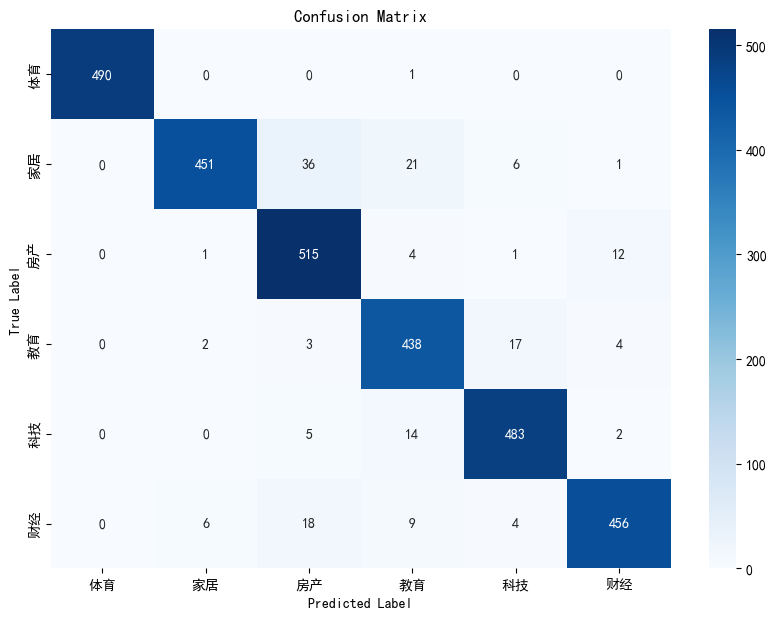

In [15]:
# 用测试集评估模型
y_test_pred = nb_classifier.predict(X_test)

# 输出基本的准确率
print("Accuracy:", accuracy_score(y_test, y_test_pred))

# 输出分类报告，包含宏平均和微平均的精确率、召回率、F1分数等
print("Classification Report:")
# digits参数指定了输出数据的小数位数
print(classification_report(y_test, y_test_pred, digits=4))

# 可视化混淆矩阵
#获取类标签
class_labels=np.unique(np.concatenate((y_test,y_test_pred)))

# 计算混淆矩阵
conf_matrix = confusion_matrix(y_test, y_test_pred,labels=class_labels)

# 直接输出混淆矩阵
print("Confusion Matrix:")
print(conf_matrix)

# 可视化
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5 分类器应用

In [16]:
# 输入待预测的文本
text = input("请输入待预测的文本：")
# 使用 jieba 对输入文本进行分词
cut_text = ' '.join(jieba.cut(text))

# 使用训练好的 TfidfVectorizer 转换文本为特征向量
# 这里使用的是 transform 而不是 fit_transform
# transform 方法根据训练阶段学到的词汇表将文本转换为特征向量，而不会重新计算词汇表或调整任何参数。
text_features = vectorizer.transform([cut_text])

# 预测文本的类别
y_predict = nb_classifier.predict(text_features)

print(f"预测的类别是: {y_predict[0]}")

请输入待预测的文本：证券时报记者 邓雄鹰  保险资金配置权益资产持续推进。据证券时报记者统计，今年以来，6家保险公司共发布11次举牌公告，举牌次数超过去年同期，且已超过2023年全年，创下单季举牌数量新高。  据了解，多家险企相关负责人认为今年股市存在结构性机会，预计权益投资比例将适度提升。  举牌次数创新高  近日，瑞众人寿受托人华夏久盈资管通过沪港通从港股二级市场买入100万股中国神华的股份，交易完成后持有中国神华H股1.69亿股，占该公司H股股本的5%，达到举牌线。  以3月20日中国神华H股收盘价31.65港元/股为基准及当日人民币汇率来计算，瑞众人寿持有中国神华H股的账面余额达人民币49.36亿元。这也是3月份瑞众人寿第二次举牌，不久前，瑞众人寿刚刚完成了对中信银行H股的举牌。  据中国保险行业协会披露，2025年以来，共有6家险企发布11次举牌公告，其中平安人寿4次，长城人寿2次，瑞众人寿2次，中国人寿、新华人寿以及阳光人寿各一次，共涉及10只股票。  这一数量超过了2024年同期，也远超2023年险资全年举牌量，创下单季度举牌量新高。数据显示，2024年保险公司共发布20次举牌公告，其中上半年4次。  从险资举牌标的来看，保险公司今年举牌的股票包括招商银行、邮储银行、农业银行、中信银行、杭州银行、中国儒意、中国水务、大唐新能源、中国神华和电投产融，多数为H股。总体来看，举牌标的主要涵盖银行、公用事业等领域。  业内人士分析，作为中长期资金的代表，险资频频举牌一方面是为了响应中长期资金入市号召，另一方面与新金融工具准则实施和利率持续下行有关。通过加大对高股息个股投资和增加长期股权投资规模，有利于推动收益和报表更加稳定。此外，险资举牌回升也受当下长债利率持续下滑、非标等高收益项目缩减等“资产荒”影响。  险资增仓脚步加快  险资举牌热是保险公司资产配置策略调整的具体表现。在长期低利率环境下，权益投资对提升收益的重要性日益凸显。  例如，中国人寿2024年积极布局权益投资，在市场低位把握机会入市，全年净加仓超1000亿元，权益投资收益大幅提升。中国太保2024年末股票和权益型基金占投资资产的11.2%，较上年末上升0.5个百分点。  与其他机构不同，险资注重以穿越周期的视角开展权益配置。在投资标的上，注重高股息、低波红利股配置与代表经济发展方向的成长股相结合